In [59]:
import pandas as pd
import numpy as np

df = pd.read_csv("mal_anime_dataset.csv")
df

,mal_id,title,type,episodes,score,status,year
0,1,Cowboy Bebop,TV,26.0,8.75,Finished Airing,1998.0
1,5,Cowboy Bebop: Tengoku no Tobira,Movie,1.0,8.38,Finished Airing,NaN
2,6,Trigun,TV,26.0,8.22,Finished Airing,1998.0
3,7,Witch Hunter Robin,TV,26.0,7.23,Finished Airing,2002.0
4,8,Bouken Ou Beet,TV,52.0,6.92,Finished Airing,2004.0
...,...,...,...,...,...,...,...
29005,62558,Koikeya SDGs Gekijou Suss to Tina Season 3,TV,13.0,NaN,Finished Airing,2022.0
29006,62559,Koikeya SDGs Gekijou Suss to Tina Season 4,TV,13.0,NaN,Finished Airing,2023.0
29007,62560,Koikeya SDGs Gekijou Suss to Tina Season 5,TV,13.0,NaN,Finished Airing,2024.0
29008,62561,Koikeya SDGs Gekijou Suss to Tina Season 6,TV,13.0,NaN,Not yet aired,2025.0


In [60]:
df["year"] = df["year"].astype('Int64')
df["episodes"] = df["episodes"].astype('Int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29010 entries, 0 to 29009
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mal_id    29010 non-null  int64  
 1   title     29010 non-null  object 
 2   type      28938 non-null  object 
 3   episodes  28309 non-null  Int64  
 4   score     18903 non-null  float64
 5   status    29010 non-null  object 
 6   year      6271 non-null   Int64  
dtypes: Int64(2), float64(1), int64(1), object(3)
memory usage: 1.6+ MB


In [61]:
mean_values = df.mean(numeric_only=True)
mean_values

mal_id      34003.145502
episodes       14.107033
score           6.389898
year         2010.045607
dtype: Float64

In [62]:
sorted_by_rated = df.sort_values(by="score", ascending=False)
print("Top Rated Anime")
sorted_by_rated.iloc[:10]

Top Rated Anime


,mal_id,title,type,episodes,score,status,year
23045,52991,Sousou no Frieren,TV,28,9.29,Finished Airing,2023
3960,5114,Fullmetal Alchemist: Brotherhood,TV,64,9.10,Finished Airing,2009
5663,9253,Steins;Gate,TV,24,9.07,Finished Airing,2011
9872,28977,Gintama°,TV,51,9.05,Finished Airing,2015
14840,38524,Shingeki no Kyojin Season 3 Part 2,TV,10,9.05,Finished Airing,2019
15493,39486,Gintama: The Final,Movie,1,9.05,Finished Airing,<NA>
6452,11061,Hunter x Hunter (2011),TV,148,9.03,Finished Airing,2011
27402,60022,One Piece Fan Letter,TV Special,1,9.03,Finished Airing,<NA>
5985,9969,Gintama',TV,51,9.02,Finished Airing,2011
741,820,Ginga Eiyuu Densetsu,OVA,110,9.02,Finished Airing,<NA>


In [63]:
sorted_by_rated = df.sort_values(by="score")
print("worst Anime by the rating") 
sorted_by_rated.iloc[:10]

worst Anime by the rating


,mal_id,title,type,episodes,score,status,year
2925,3287,Tenkuu Danzai Skelter+Heaven,OVA,1,1.89,Finished Airing,<NA>
6943,13405,Utsu Musume Sayuri,Movie,1,2.01,Finished Airing,<NA>
387,413,Hametsu no Mars,OVA,1,2.23,Finished Airing,<NA>
4193,5569,Tsui no Sora,OVA,1,2.33,Finished Airing,<NA>
10976,31634,Kokuhaku,ONA,1,2.41,Finished Airing,<NA>
8587,22179,Aki no Puzzle,Movie,1,2.43,Finished Airing,<NA>
4337,5877,Abunai Sisters: Koko & Mika,OVA,10,2.56,Finished Airing,<NA>
11255,32294,Ai (ONA),ONA,1,2.68,Finished Airing,<NA>
11539,32894,Love Bites,ONA,1,2.68,Finished Airing,<NA>
4820,6953,Ningen Doubutsuen,Movie,1,2.75,Finished Airing,<NA>


In [64]:
Average_score = df.score.mean()
Average_episode = df.episodes.mean()
print("Average episode :",Average_episode)
print("Average_score :", Average_score)

Average episode : 14.107033099014448
Average_score : 6.389898428820823


In [65]:
year_distribution = df.year.value_counts().sort_index()
year_distribution.to_csv("data/year_distribution.csv")

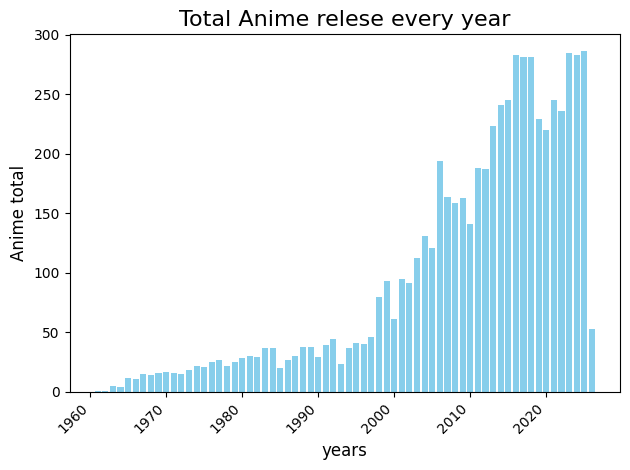

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.bar(year_distribution.index, year_distribution.values, color='skyblue')
plt.title('Total Anime relese every year', fontsize=16) # Judul lebih besar
plt.xlabel('years', fontsize=12)
plt.ylabel('Anime total', fontsize=12)
plt.xticks(fontsize=10, rotation=45, ha='right') # Label sumbu-x lebih kecil
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [67]:
print(f"the years with anime bigger realese count is {year_distribution.idxmax()} with {year_distribution.max()} anime",)

the years with anime bigger realese count is 2025 with 286 anime


In [68]:
df_clean = df.dropna(subset=["score", "year"])
avg_score_per_year = df_clean.groupby("year")["score"].mean()
avg_score_per_year.to_csv("data/avg_score_per_year.csv")

In [69]:
print(f"the years with anime bigger score is {avg_score_per_year.idxmax()} with {avg_score_per_year.max()} mean",)

the years with anime bigger score is 1996 with 7.246176470588235 mean


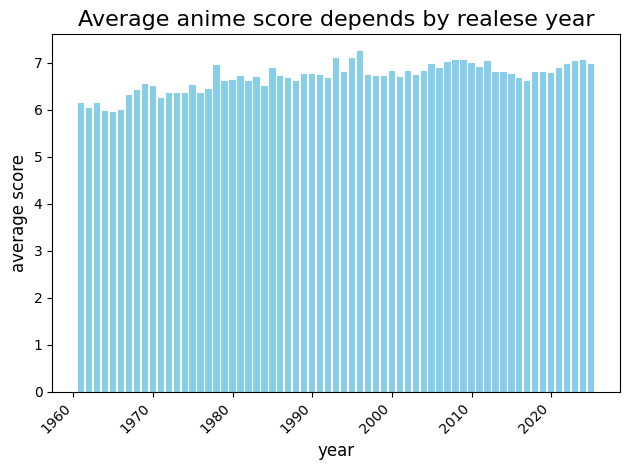

In [70]:
plt.bar(avg_score_per_year.index, avg_score_per_year.values, color='skyblue')

plt.title('Average anime score depends by realese year', fontsize=16) # Judul lebih besar
plt.xlabel('year', fontsize=12)
plt.ylabel('average score', fontsize=12)
plt.xticks(fontsize=10, rotation=45, ha='right') # Label sumbu-x lebih kecil
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [71]:
anime_1996_year = df[df.year== 1996] 
anime_1996_year

,mal_id,title,type,episodes,score,status,year
26,45,Rurouni Kenshin: Meiji Kenkaku Romantan,TV,94,8.28,Finished Airing,1996
71,92,Kidou Shinseiki Gundam X,TV,39,7.34,Finished Airing,1996
85,106,Hana yori Dango,TV,51,7.57,Finished Airing,1996
159,182,Tenkuu no Escaflowne,TV,26,7.65,Finished Airing,1996
195,218,Kidou Senkan Nadesico,TV,26,7.49,Finished Airing,1996
201,225,Dragon Ball GT,TV,64,6.51,Finished Airing,1996
211,235,Meitantei Conan,TV,<NA>,8.18,Currently Airing,1996
262,286,B'T X,TV,25,7.01,Finished Airing,1996
502,535,Slayers Next,TV,26,8.01,Finished Airing,1996
538,573,Saber Marionette J,TV,25,7.33,Finished Airing,1996


In [72]:
df.type.value_counts()

type
TV            8422
Movie         4930
OVA           4189
ONA           4106
Music         4001
Special       1756
TV Special     768
CM             489
PV             277
Name: count, dtype: int64

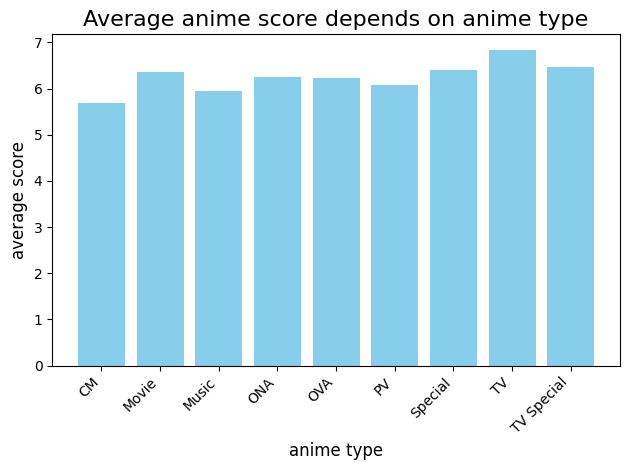

In [73]:
avg_score_per_type = df.groupby("type")["score"].mean()

plt.bar(avg_score_per_type.index, avg_score_per_type.values, color='skyblue')

plt.title('Average anime score depends on anime type', fontsize=16) # Judul lebih besar
plt.xlabel('anime type', fontsize=12)
plt.ylabel('average score', fontsize=12)
plt.xticks(fontsize=10, rotation=45, ha='right') # Label sumbu-x lebih kecil
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

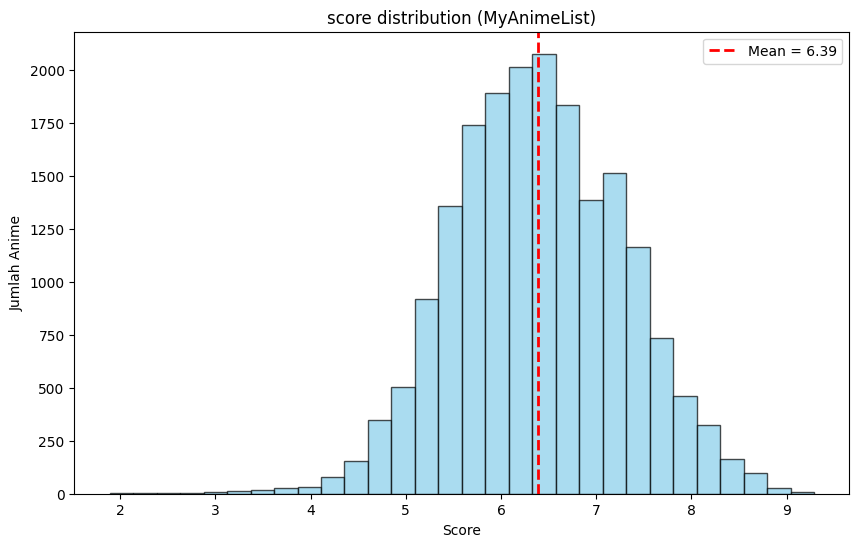

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df["score"], bins=30, alpha=0.7, color="skyblue", edgecolor="black")
plt.axvline(Average_score, color="red", linestyle="dashed", linewidth=2, label=f"Mean = {Average_score:.2f}")
plt.xlabel("Score")
plt.ylabel("Jumlah Anime")
plt.title("score distribution (MyAnimeList)")
plt.legend()
plt.show()

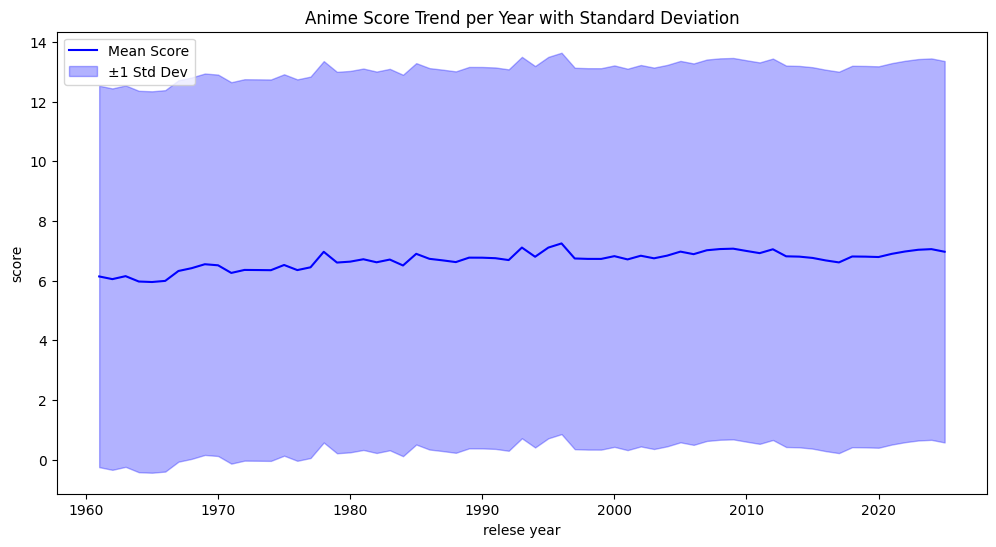

In [75]:
year = avg_score_per_year.index
means = avg_score_per_year.values

plt.figure(figsize=(12,6))
plt.plot(year, means, label="Mean Score", color="blue")
plt.fill_between(year, means-Average_score, means+Average_score, 
                 alpha=0.3, color="blue", label="±1 Std Dev")
plt.xlabel("relese year")
plt.ylabel("score")
plt.title("Anime Score Trend per Year with Standard Deviation")
plt.legend()
plt.show()

In [76]:
above_the_means = df[df.score >= Average_score].sort_values(by='score', ascending=False)
above_the_means

,mal_id,title,type,episodes,score,status,year
23045,52991,Sousou no Frieren,TV,28,9.29,Finished Airing,2023
3960,5114,Fullmetal Alchemist: Brotherhood,TV,64,9.10,Finished Airing,2009
5663,9253,Steins;Gate,TV,24,9.07,Finished Airing,2011
15493,39486,Gintama: The Final,Movie,1,9.05,Finished Airing,<NA>
14840,38524,Shingeki no Kyojin Season 3 Part 2,TV,10,9.05,Finished Airing,2019
...,...,...,...,...,...,...,...
22613,52221,Xian Wu Cangqiong,ONA,48,6.39,Finished Airing,<NA>
7547,17010,Yasashii March,Movie,1,6.39,Finished Airing,<NA>
27404,60024,Monotone,Music,1,6.39,Finished Airing,<NA>
12629,34937,Ichinen Buri no The Animation,OVA,1,6.39,Finished Airing,<NA>


In [77]:
long_running_success = df[(df.score >= Average_score) & (df.episodes >= 70)].sort_values(by='score', ascending=False)
print("long-running success anime")
long_running_success.iloc[:20]

long-running success anime


,mal_id,title,type,episodes,score,status,year
6452,11061,Hunter x Hunter (2011),TV,148,9.03,Finished Airing,2011
741,820,Ginga Eiyuu Densetsu,OVA,110,9.02,Finished Airing,<NA>
833,918,Gintama,TV,201,8.93,Finished Airing,2006
9,19,Monster,TV,74,8.89,Finished Airing,2004
239,263,Hajime no Ippo,TV,75,8.78,Finished Airing,2000
148,170,Slam Dunk,TV,101,8.55,Finished Airing,1993
6728,12431,Uchuu Kyoudai,TV,99,8.48,Finished Airing,2012
368,392,Yuu☆Yuu☆Hakusho,TV,112,8.46,Finished Airing,1992
21967,51039,Doupo Cangqiong: Nian Fan,ONA,209,8.44,Currently Airing,<NA>
11744,33255,Saiki Kusuo no Ψ-nan,TV,120,8.41,Finished Airing,2016


In [78]:
print(f"BEST ANIME ALL OF THE TIME")
df[df.title == "Monster"]

BEST ANIME ALL OF THE TIME


,mal_id,title,type,episodes,score,status,year
9,19,Monster,TV,74,8.89,Finished Airing,2004
